# Лабораторная работа №3 ОБУЧЕНИЕ С УЧИТЕЛЕМ. ЗАДАЧА КЛАССИФИКАЦИИ 

## Загрузка и подготовка данных

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, RocCurveDisplay, classification_report

import optuna
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import uniform, randint

from my_metrics_class import *
from my_algs import MyKNNClassifier



RNG_SEED = 42
np.random.seed(seed=RNG_SEED)

### Загрузка датасета

In [118]:
df = pd.read_csv('../data/final_data_wine.csv')
df

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
5970,4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
5971,4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
5972,4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            5974 non-null   int64  
 1   fixed acidity         5974 non-null   float64
 2   volatile acidity      5974 non-null   float64
 3   citric acid           5974 non-null   float64
 4   residual sugar        5974 non-null   float64
 5   chlorides             5974 non-null   float64
 6   free sulfur dioxide   5974 non-null   float64
 7   total sulfur dioxide  5974 non-null   float64
 8   density               5974 non-null   float64
 9   pH                    5974 non-null   float64
 10  sulphates             5974 non-null   float64
 11  alcohol               5974 non-null   float64
 12  quality               5974 non-null   int64  
 13  type                  5974 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 653.5 KB


### Выделеение целевого признака и предиктора, разделение на выборки

In [120]:
X = df.drop(columns=['type'])
y = df['type']
print(X.shape, y.shape)
print(y.value_counts())

(5974, 13) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


### Разделение данных

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RNG_SEED)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, X_val.shape, y_test.shape)


(3584, 13) (1195, 13) (1195, 13)
(3584,) (1195, 13) (1195,)


Задача бинарной классификации (2 признака 0,1 - белое и красное вино). В данных имеется явный дисбаланс классов - красного вина в 4 раза меньше белого

### Балансировка

In [122]:
y_train.value_counts()

type
0    2745
1     839
Name: count, dtype: int64

In [123]:
oversample = SMOTE()

X_train_bal, y_train_bal = oversample.fit_resample(X_train, y_train)
y_train_bal.value_counts()

type
0    2745
1    2745
Name: count, dtype: int64

### Вспомогательные функции

In [124]:
def calculate_metrics(y_true, y_pred):
    return {
        'F1': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred)
    }

def print_cv_results_table(cv_scores, model_name="Model"):
    metric_mapping = {
        'F1': 'test_f1_weighted',
        'Accuracy': 'test_accuracy',
        'Precision': 'test_precision_weighted',
        'Recall': 'test_recall_weighted'
    }
    
    data = {'Fold': list(range(len(cv_scores['test_accuracy'])))}
    for col_name, key in metric_mapping.items():
        data[col_name] = cv_scores[key]
        
    df = pd.DataFrame(data).set_index('Fold')
    
    df.loc['Mean'] = df.mean()
    df.loc['Std'] = df.std()
    
    print(f"\nРезультаты 10-Fold CV для {model_name}")
    display(df.style.format('{:.4f}').apply(
        lambda row: ['background-color: #FFFF00' if row.name == 'Mean' else '' for _ in row], 
        axis=1
    ))

def fmt(val, metric_name):
    prec = 2 if metric_name == 'F1' else 4
    return f"{val:.{prec}f}"

## Основные классификаторы


 Обучение: Logistic Regression



Результаты 10-Fold CV для Logistic Regression


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9917,0.9917,0.9920,0.9917
2,0.9917,0.9917,0.9920,0.9917
3,1.0000,1.0000,1.0000,1.0000
4,0.9917,0.9917,0.9920,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


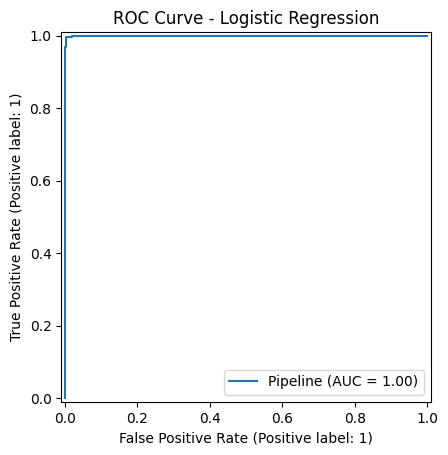


 Обучение: kNN

Результаты 10-Fold CV для kNN


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.8239,0.8250,0.8229,0.8250
1,0.7740,0.7667,0.7853,0.7667
2,0.8426,0.8417,0.8437,0.8417
3,0.6935,0.6917,0.6955,0.6917
4,0.8239,0.8250,0.8229,0.8250
5,0.8209,0.8151,0.8311,0.8151
6,0.7957,0.7983,0.7936,0.7983
7,0.7815,0.7815,0.7815,0.7815
8,0.7912,0.7899,0.7926,0.7899


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


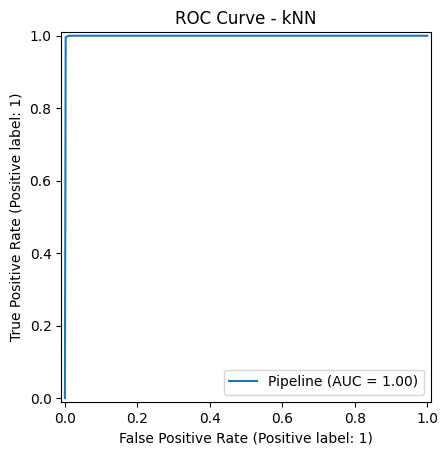


 Обучение: Naive Bayes

Результаты 10-Fold CV для Naive Bayes


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9754,0.9750,0.9774,0.9750
2,0.9917,0.9917,0.9920,0.9917
3,0.9835,0.9833,0.9844,0.9833
4,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.98 | Acc: 0.9891
Confusion Matrix:
 [[905  10]
 [  3 277]]


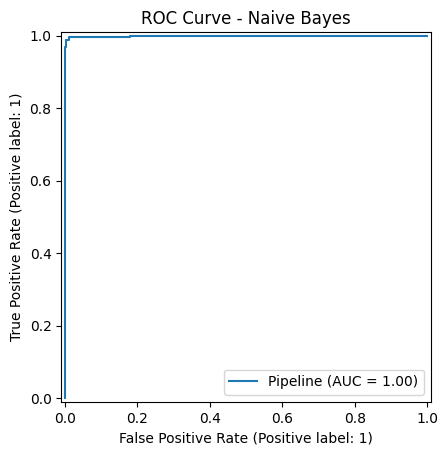


 Обучение: SVC (Linear)

Результаты 10-Fold CV для SVC (Linear)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9916,0.9917,0.9918,0.9917
1,0.9917,0.9917,0.9920,0.9917
2,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000
4,0.9917,0.9917,0.9920,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000


Test F1: 0.99 | Acc: 0.9958
Confusion Matrix:
 [[912   3]
 [  2 278]]


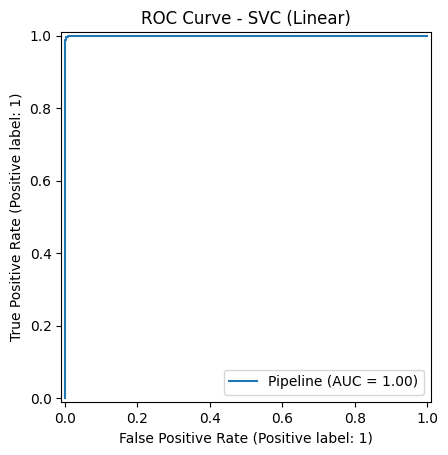


 Обучение: SVC (Poly)

Результаты 10-Fold CV для SVC (Poly)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.7041,0.7167,0.6951,0.7167
1,0.6654,0.7667,0.5878,0.7667
2,0.6654,0.7667,0.5878,0.7667
3,0.6654,0.7667,0.5878,0.7667
4,0.6654,0.7667,0.5878,0.7667
5,0.6627,0.7647,0.5848,0.7647
6,0.6627,0.7647,0.5848,0.7647
7,0.6627,0.7647,0.5848,0.7647
8,0.6627,0.7647,0.5848,0.7647


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


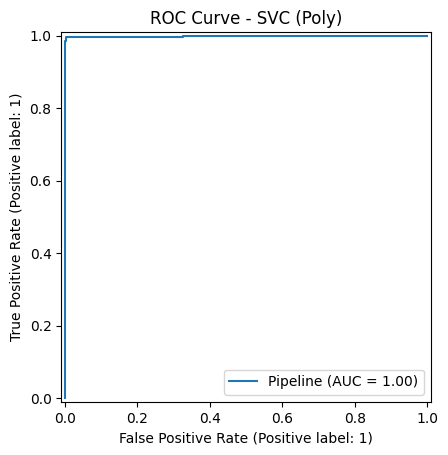


 Обучение: SVC (Sigmoid)

Результаты 10-Fold CV для SVC (Sigmoid)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.6390,0.6667,0.6176,0.6667
1,0.6741,0.6667,0.6828,0.6667
2,0.6107,0.6083,0.6131,0.6083
3,0.6990,0.7167,0.6873,0.7167
4,0.7298,0.7333,0.7267,0.7333
5,0.6546,0.6639,0.6464,0.6639
6,0.6180,0.5966,0.6493,0.5966
7,0.7010,0.6975,0.7049,0.6975
8,0.6471,0.6471,0.6471,0.6471


Test F1: 0.97 | Acc: 0.9841
Confusion Matrix:
 [[906   9]
 [ 10 270]]


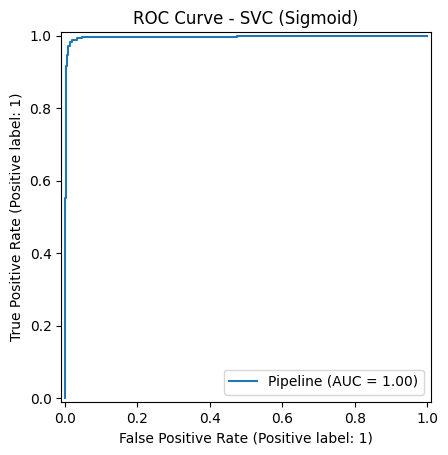

In [125]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RNG_SEED),
    "kNN": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": GaussianNB(),
    "SVC (Linear)": SVC(kernel='linear', random_state=RNG_SEED, cache_size=8000, probability=False),
    "SVC (Poly)": SVC(kernel='poly', random_state=RNG_SEED, cache_size=8000, probability=False),
    "SVC (Sigmoid)": SVC(kernel='sigmoid', random_state=RNG_SEED, cache_size=8000, probability=False)
}

holdout_results = []
cv_results = []
trained_models = {}

cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG_SEED)
metrics_list = ['F1', 'Accuracy', 'Precision', 'Recall']

for name, clf in classifiers.items():
    print(f"\n Обучение: {name}")
    
    cv_scores = cross_validate(
        clf, X_val, y_val, cv=cv_strategy,
        scoring=['f1_weighted', 'accuracy', 'precision_weighted', 'recall_weighted'],
        n_jobs=-1
    )
    
    cv_row = {"Classifier": name}
    for key, met in zip(['f1_weighted', 'accuracy', 'precision_weighted', 'recall_weighted'], metrics_list):
        mean_v, std_v = cv_scores[f'test_{key}'].mean(), cv_scores[f'test_{key}'].std()
        cv_row[('K-fold (CV)', met)] = f"{mean_v:.2f} ± {std_v:.2f}" if met == 'F1' else f"{mean_v:.4f} ± {std_v:.4f}"
    cv_results.append(cv_row)

    print_cv_results_table(cv_scores, model_name=name)
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_m = calculate_metrics(y_train, y_train_pred)
    test_m = calculate_metrics(y_test, y_test_pred)
    
    row_holdout = {'Classifier': name}
    for metric in metrics_list:
        row_holdout[('Train Data', metric)] = fmt(train_m[metric], metric)
        row_holdout[('Test Data', metric)]  = fmt(test_m[metric], metric)
    holdout_results.append(row_holdout)
    
    print(f"Test F1: {test_m['F1']:.2f} | Acc: {test_m['Accuracy']:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f'ROC Curve - {name}')
    plt.show()


In [126]:
holdout_results

[{'Classifier': 'Logistic Regression',
  ('Train Data', 'F1'): '0.99',
  ('Test Data', 'F1'): '0.99',
  ('Train Data', 'Accuracy'): '0.9967',
  ('Test Data', 'Accuracy'): '0.9967',
  ('Train Data', 'Precision'): '0.9928',
  ('Test Data', 'Precision'): '0.9894',
  ('Train Data', 'Recall'): '0.9928',
  ('Test Data', 'Recall'): '0.9964'},
 {'Classifier': 'kNN',
  ('Train Data', 'F1'): '0.99',
  ('Test Data', 'F1'): '0.99',
  ('Train Data', 'Accuracy'): '0.9961',
  ('Test Data', 'Accuracy'): '0.9967',
  ('Train Data', 'Precision'): '0.9847',
  ('Test Data', 'Precision'): '0.9894',
  ('Train Data', 'Recall'): '0.9988',
  ('Test Data', 'Recall'): '0.9964'},
 {'Classifier': 'Naive Bayes',
  ('Train Data', 'F1'): '0.98',
  ('Test Data', 'F1'): '0.98',
  ('Train Data', 'Accuracy'): '0.9922',
  ('Test Data', 'Accuracy'): '0.9891',
  ('Train Data', 'Precision'): '0.9765',
  ('Test Data', 'Precision'): '0.9652',
  ('Train Data', 'Recall'): '0.9905',
  ('Test Data', 'Recall'): '0.9893'},
 {'Classif

In [127]:
cv_results

[{'Classifier': 'Logistic Regression',
  ('K-fold (CV)', 'F1'): '1.00 ± 0.00',
  ('K-fold (CV)', 'Accuracy'): '0.9950 ± 0.0041',
  ('K-fold (CV)', 'Precision'): '0.9951 ± 0.0040',
  ('K-fold (CV)', 'Recall'): '0.9950 ± 0.0041'},
 {'Classifier': 'kNN',
  ('K-fold (CV)', 'F1'): '0.80 ± 0.04',
  ('K-fold (CV)', 'Accuracy'): '0.7958 ± 0.0411',
  ('K-fold (CV)', 'Precision'): '0.7990 ± 0.0399',
  ('K-fold (CV)', 'Recall'): '0.7958 ± 0.0411'},
 {'Classifier': 'Naive Bayes',
  ('K-fold (CV)', 'F1'): '0.99 ± 0.01',
  ('K-fold (CV)', 'Accuracy'): '0.9925 ± 0.0079',
  ('K-fold (CV)', 'Precision'): '0.9929 ± 0.0072',
  ('K-fold (CV)', 'Recall'): '0.9925 ± 0.0079'},
 {'Classifier': 'SVC (Linear)',
  ('K-fold (CV)', 'F1'): '1.00 ± 0.00',
  ('K-fold (CV)', 'Accuracy'): '0.9967 ± 0.0041',
  ('K-fold (CV)', 'Precision'): '0.9967 ± 0.0040',
  ('K-fold (CV)', 'Recall'): '0.9967 ± 0.0041'},
 {'Classifier': 'SVC (Poly)',
  ('K-fold (CV)', 'F1'): '0.67 ± 0.01',
  ('K-fold (CV)', 'Accuracy'): '0.7607 ± 0.01

По предоставленным результатам видно, что все модели достаточно хорошо отработали (f1)

## Оптимизация grid, random, optuna

In [ ]:
PARAM_CONFIGS = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
    },
    "kNN": {
        "n_neighbors": [1, 3, 5, 7, 9],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan", "chebyshev"]
    },
    "Naive Bayes": {
        "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    },
    "SVC (Linear)": {
        "C": [0.01, 0.1, 1, 10, 100]
    },
    "SVC (Poly)": {
        "C": [0.1, 1, 10],
        "degree": [2, 3, 4],
        "gamma": ["scale", "auto"],
        "coef0": [0.0, 0.5, 1.0]
    },
    "SVC (Sigmoid)": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "coef0": [-1.0, 0.0, 1.0]
    }
}

In [129]:
def tune_model(base_model, model_name, method='grid'):
    params = PARAM_CONFIGS.get(model_name, {})
    if not params:
        print(f"   Параметры для {model_name} не заданы. Используется модель по умолчанию.")
        return base_model, {}

    print(f"   Оптимизация ({method.upper()}): {model_name}")
    
    if method == 'grid':
        search = GridSearchCV(base_model, params, cv=3, scoring='f1_weighted', n_jobs=-1)
        search.fit(X_train_bal, y_train_bal)
        best_params = search.best_params_
        print(f"   GridSearch выбрал: {best_params}")
        return search.best_estimator_, best_params
        
    elif method == 'random':
        search = RandomizedSearchCV(base_model, params, n_iter=15, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42)
        search.fit(X_train_bal, y_train_bal)
        best_params = search.best_params_
        print(f"   RandomizedSearch выбрал: {best_params}")
        return search.best_estimator_, best_params
        
    elif method == 'optuna':
        def objective(trial):
            tuned_params = {}
            for param_name, param_values in params.items():
                if all(isinstance(v, int) for v in param_values):
                    tuned_params[param_name] = trial.suggest_int(param_name, min(param_values), max(param_values))
                else:
                    tuned_params[param_name] = trial.suggest_categorical(param_name, param_values)
            clf = base_model.__class__(**tuned_params)
            return cross_val_score(clf, X_train_bal, y_train_bal, cv=3, scoring='f1_weighted').mean()
        
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=20, show_progress_bar=False)
        best_params = study.best_params
        print(f"   Optuna выбрала: {best_params}")
        
        best_model = base_model.__class__(**best_params)
        best_model.fit(X_train_bal, y_train_bal)
        return best_model, best_params

МЕТОД ОПТИМИЗАЦИИ: GRID

 Модель: Logistic Regression
   Оптимизация (GRID): Logistic Regression


   GridSearch выбрал: {'C': 1}

Результаты 10-Fold CV для Logistic Regression


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9917,0.9917,0.9920,0.9917
2,0.9917,0.9917,0.9920,0.9917
3,1.0000,1.0000,1.0000,1.0000
4,0.9917,0.9917,0.9920,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


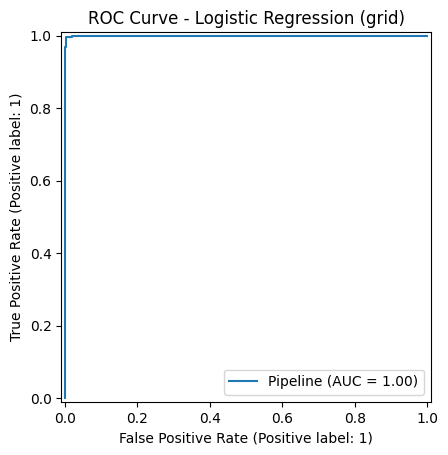


 Модель: kNN
   Оптимизация (GRID): kNN
   GridSearch выбрал: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}

Результаты 10-Fold CV для kNN


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9245,0.9250,0.9242,0.9250
1,0.9156,0.9167,0.9152,0.9167
2,0.9185,0.9167,0.9228,0.9167
3,0.8500,0.8500,0.8500,0.8500
4,0.9270,0.9250,0.9329,0.9250
5,0.9415,0.9412,0.9421,0.9412
6,0.9328,0.9328,0.9328,0.9328
7,0.9502,0.9496,0.9514,0.9496
8,0.9169,0.9160,0.9186,0.9160


Test F1: 1.00 | Acc: 0.9983
Confusion Matrix:
 [[913   2]
 [  0 280]]


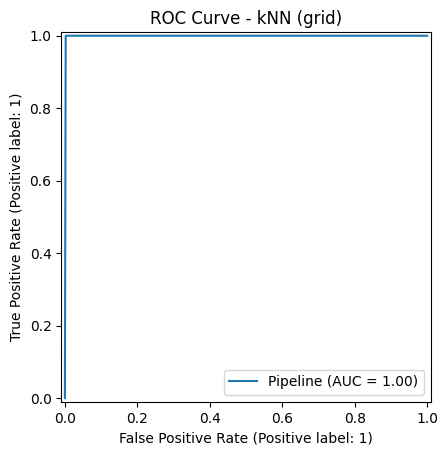


 Модель: Naive Bayes
   Оптимизация (GRID): Naive Bayes
   GridSearch выбрал: {'var_smoothing': 1e-08}

Результаты 10-Fold CV для Naive Bayes


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9754,0.9750,0.9774,0.9750
2,0.9835,0.9833,0.9844,0.9833
3,0.9835,0.9833,0.9844,0.9833
4,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.98 | Acc: 0.9891
Confusion Matrix:
 [[905  10]
 [  3 277]]


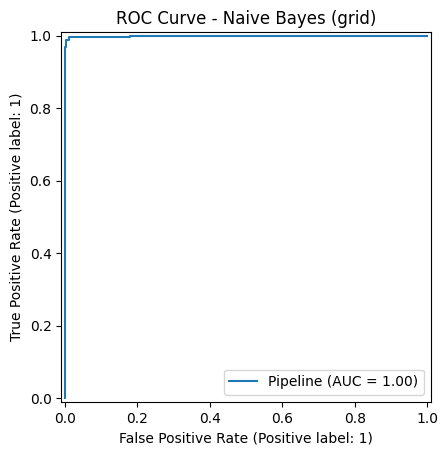


 Модель: SVC (Linear)
   Оптимизация (GRID): SVC (Linear)
   GridSearch выбрал: {'C': 0.1}

Результаты 10-Fold CV для SVC (Linear)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9917,0.9917,0.9920,0.9917
2,0.9917,0.9917,0.9920,0.9917
3,0.9835,0.9833,0.9844,0.9833
4,0.9917,0.9917,0.9920,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


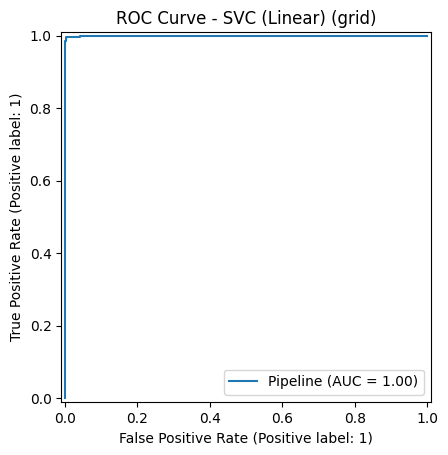


 Модель: SVC (Poly)
   Параметры для SVC (Poly) не заданы. Используется модель по умолчанию.

Результаты 10-Fold CV для SVC (Poly)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.7041,0.7167,0.6951,0.7167
1,0.6654,0.7667,0.5878,0.7667
2,0.6654,0.7667,0.5878,0.7667
3,0.6654,0.7667,0.5878,0.7667
4,0.6654,0.7667,0.5878,0.7667
5,0.6627,0.7647,0.5848,0.7647
6,0.6627,0.7647,0.5848,0.7647
7,0.6627,0.7647,0.5848,0.7647
8,0.6627,0.7647,0.5848,0.7647


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


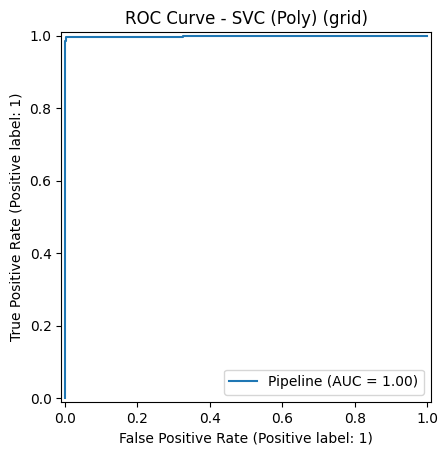


 Модель: SVC (Sigmoid)
   Оптимизация (GRID): SVC (Sigmoid)
   GridSearch выбрал: {'C': 0.1, 'coef0': -1.0, 'gamma': 'scale'}

Результаты 10-Fold CV для SVC (Sigmoid)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.6654,0.7667,0.5878,0.7667
1,0.6654,0.7667,0.5878,0.7667
2,0.6654,0.7667,0.5878,0.7667
3,0.6654,0.7667,0.5878,0.7667
4,0.6654,0.7667,0.5878,0.7667
5,0.6627,0.7647,0.5848,0.7647
6,0.6627,0.7647,0.5848,0.7647
7,0.6627,0.7647,0.5848,0.7647
8,0.6627,0.7647,0.5848,0.7647


Test F1: 0.99 | Acc: 0.9958
Confusion Matrix:
 [[911   4]
 [  1 279]]


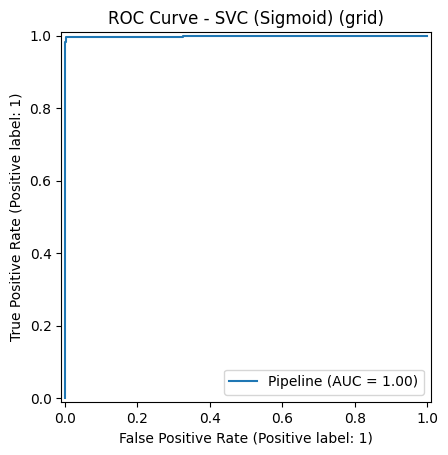

МЕТОД ОПТИМИЗАЦИИ: RANDOM

 Модель: Logistic Regression
   Оптимизация (RANDOM): Logistic Regression
   RandomizedSearch выбрал: {'C': 1}

Результаты 10-Fold CV для Logistic Regression


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9917,0.9917,0.9920,0.9917
2,0.9917,0.9917,0.9920,0.9917
3,1.0000,1.0000,1.0000,1.0000
4,0.9917,0.9917,0.9920,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


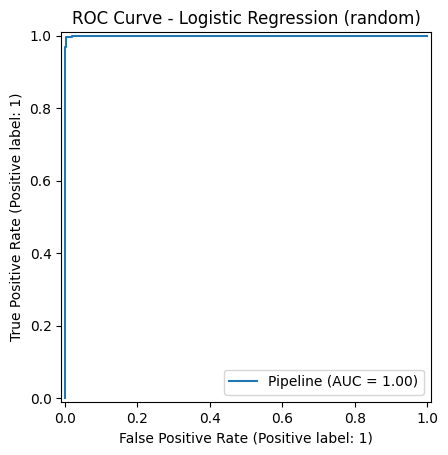


 Модель: kNN
   Оптимизация (RANDOM): kNN
   RandomizedSearch выбрал: {'weights': 'distance', 'n_neighbors': 1, 'metric': 'manhattan'}

Результаты 10-Fold CV для kNN


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9245,0.9250,0.9242,0.9250
1,0.9156,0.9167,0.9152,0.9167
2,0.9185,0.9167,0.9228,0.9167
3,0.8500,0.8500,0.8500,0.8500
4,0.9270,0.9250,0.9329,0.9250
5,0.9415,0.9412,0.9421,0.9412
6,0.9328,0.9328,0.9328,0.9328
7,0.9502,0.9496,0.9514,0.9496
8,0.9169,0.9160,0.9186,0.9160


Test F1: 1.00 | Acc: 0.9983
Confusion Matrix:
 [[913   2]
 [  0 280]]


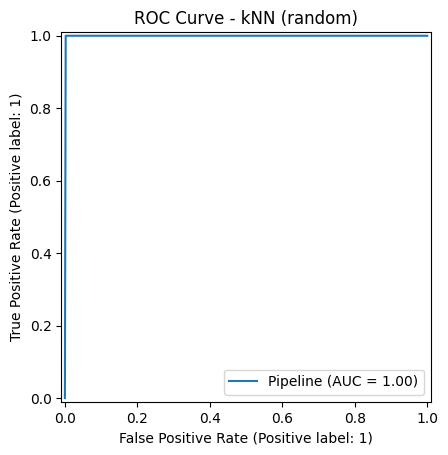


 Модель: Naive Bayes
   Оптимизация (RANDOM): Naive Bayes
   RandomizedSearch выбрал: {'var_smoothing': 1e-08}

Результаты 10-Fold CV для Naive Bayes


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9754,0.9750,0.9774,0.9750
2,0.9835,0.9833,0.9844,0.9833
3,0.9835,0.9833,0.9844,0.9833
4,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.98 | Acc: 0.9891
Confusion Matrix:
 [[905  10]
 [  3 277]]


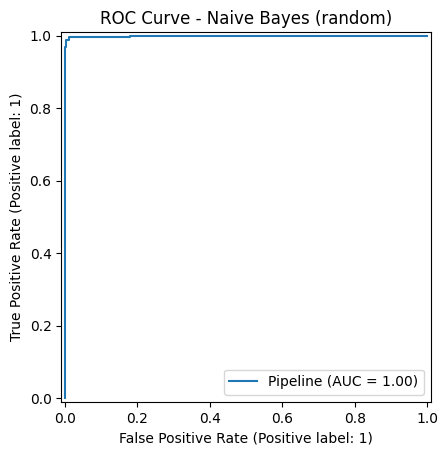


 Модель: SVC (Linear)
   Оптимизация (RANDOM): SVC (Linear)
   RandomizedSearch выбрал: {'C': 0.1}

Результаты 10-Fold CV для SVC (Linear)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9917,0.9917,0.9920,0.9917
2,0.9917,0.9917,0.9920,0.9917
3,0.9835,0.9833,0.9844,0.9833
4,0.9917,0.9917,0.9920,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


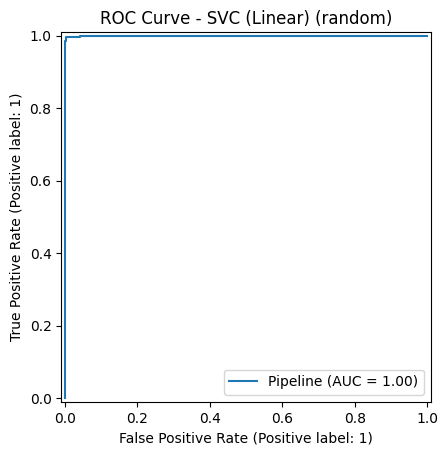


 Модель: SVC (Poly)
   Параметры для SVC (Poly) не заданы. Используется модель по умолчанию.

Результаты 10-Fold CV для SVC (Poly)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.7041,0.7167,0.6951,0.7167
1,0.6654,0.7667,0.5878,0.7667
2,0.6654,0.7667,0.5878,0.7667
3,0.6654,0.7667,0.5878,0.7667
4,0.6654,0.7667,0.5878,0.7667
5,0.6627,0.7647,0.5848,0.7647
6,0.6627,0.7647,0.5848,0.7647
7,0.6627,0.7647,0.5848,0.7647
8,0.6627,0.7647,0.5848,0.7647


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


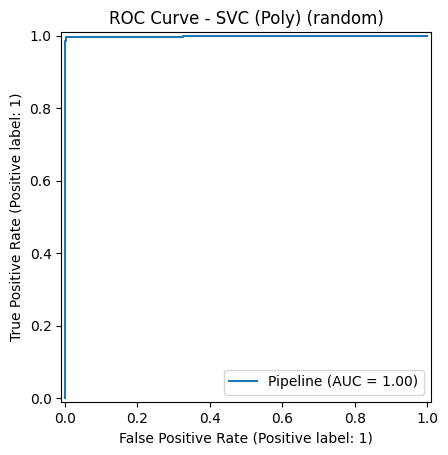


 Модель: SVC (Sigmoid)
   Оптимизация (RANDOM): SVC (Sigmoid)
   RandomizedSearch выбрал: {'gamma': 'scale', 'coef0': -1.0, 'C': 0.1}

Результаты 10-Fold CV для SVC (Sigmoid)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.6654,0.7667,0.5878,0.7667
1,0.6654,0.7667,0.5878,0.7667
2,0.6654,0.7667,0.5878,0.7667
3,0.6654,0.7667,0.5878,0.7667
4,0.6654,0.7667,0.5878,0.7667
5,0.6627,0.7647,0.5848,0.7647
6,0.6627,0.7647,0.5848,0.7647
7,0.6627,0.7647,0.5848,0.7647
8,0.6627,0.7647,0.5848,0.7647


Test F1: 0.99 | Acc: 0.9958
Confusion Matrix:
 [[911   4]
 [  1 279]]


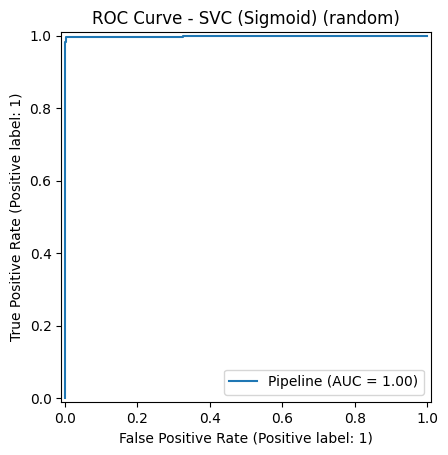

[I 2026-04-13 23:18:47,617] A new study created in memory with name: no-name-4dc7f7cb-d318-4b76-b857-faaf83d0c5c1


МЕТОД ОПТИМИЗАЦИИ: OPTUNA

 Модель: Logistic Regression
   Оптимизация (OPTUNA): Logistic Regression


[I 2026-04-13 23:18:47,791] Trial 0 finished with value: 0.99471762056905 and parameters: {'C': 100}. Best is trial 0 with value: 0.99471762056905.
[I 2026-04-13 23:18:47,950] Trial 1 finished with value: 0.9950819487745165 and parameters: {'C': 0.1}. Best is trial 1 with value: 0.9950819487745165.
[I 2026-04-13 23:18:48,110] Trial 2 finished with value: 0.9947176427610555 and parameters: {'C': 10}. Best is trial 1 with value: 0.9950819487745165.
[I 2026-04-13 23:18:48,274] Trial 3 finished with value: 0.99471762056905 and parameters: {'C': 100}. Best is trial 1 with value: 0.9950819487745165.
[I 2026-04-13 23:18:48,437] Trial 4 finished with value: 0.9950819487745165 and parameters: {'C': 0.1}. Best is trial 1 with value: 0.9950819487745165.
[I 2026-04-13 23:18:48,594] Trial 5 finished with value: 0.9958105525338237 and parameters: {'C': 1}. Best is trial 5 with value: 0.9958105525338237.
[I 2026-04-13 23:18:48,750] Trial 6 finished with value: 0.9950819487745165 and parameters: {'C':

   Optuna выбрала: {'C': 1}

Результаты 10-Fold CV для Logistic Regression


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,1.0000,1.0000,1.0000,1.0000
2,0.9917,0.9917,0.9920,0.9917
3,0.9917,0.9917,0.9920,0.9917
4,0.9917,0.9917,0.9920,0.9917
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


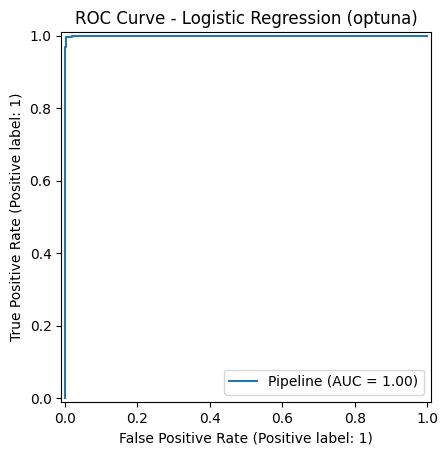

[I 2026-04-13 23:18:51,089] A new study created in memory with name: no-name-6b2d1278-04f6-4787-963d-a78c483adde5
[I 2026-04-13 23:18:51,150] Trial 0 finished with value: 0.9477722072681029 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 0 with value: 0.9477722072681029.



 Модель: kNN
   Оптимизация (OPTUNA): kNN


[I 2026-04-13 23:18:51,207] Trial 1 finished with value: 0.9680924823764602 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: 0.9680924823764602.
[I 2026-04-13 23:18:51,265] Trial 2 finished with value: 0.8487023736655117 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'chebyshev'}. Best is trial 1 with value: 0.9680924823764602.
[I 2026-04-13 23:18:51,322] Trial 3 finished with value: 0.9563846192960598 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: 0.9680924823764602.
[I 2026-04-13 23:18:51,377] Trial 4 finished with value: 0.864309764150228 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'chebyshev'}. Best is trial 1 with value: 0.9680924823764602.
[I 2026-04-13 23:18:51,438] Trial 5 finished with value: 0.9027205938688304 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'metric': 'chebyshev'}. Best is trial 1 with

   Optuna выбрала: {'n_neighbors': 1, 'weights': 'distance', 'metric': 'manhattan'}

Результаты 10-Fold CV для kNN


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9245,0.9250,0.9242,0.9250
1,0.9156,0.9167,0.9152,0.9167
2,0.9185,0.9167,0.9228,0.9167
3,0.8500,0.8500,0.8500,0.8500
4,0.9270,0.9250,0.9329,0.9250
5,0.9415,0.9412,0.9421,0.9412
6,0.9328,0.9328,0.9328,0.9328
7,0.9502,0.9496,0.9514,0.9496
8,0.9169,0.9160,0.9186,0.9160


Test F1: 1.00 | Acc: 0.9983
Confusion Matrix:
 [[913   2]
 [  0 280]]


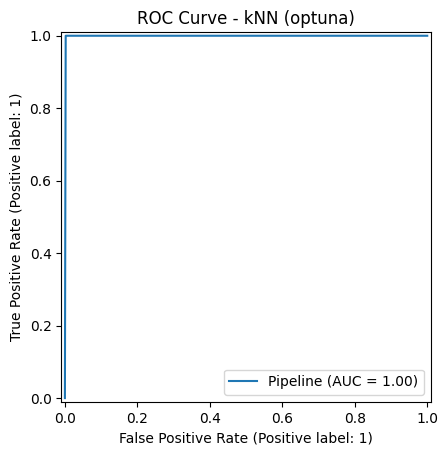

[I 2026-04-13 23:18:52,812] A new study created in memory with name: no-name-89c3b6d7-5ee6-405f-aea2-b481b586b434
[I 2026-04-13 23:18:52,844] Trial 0 finished with value: 0.9777709616950085 and parameters: {'var_smoothing': 1e-06}. Best is trial 0 with value: 0.9777709616950085.
[I 2026-04-13 23:18:52,894] Trial 1 finished with value: 0.9777709616950085 and parameters: {'var_smoothing': 1e-06}. Best is trial 0 with value: 0.9777709616950085.
[I 2026-04-13 23:18:52,938] Trial 2 finished with value: 0.9923496588954155 and parameters: {'var_smoothing': 1e-08}. Best is trial 2 with value: 0.9923496588954155.
[I 2026-04-13 23:18:52,976] Trial 3 finished with value: 0.9923496588954155 and parameters: {'var_smoothing': 1e-08}. Best is trial 2 with value: 0.9923496588954155.
[I 2026-04-13 23:18:53,009] Trial 4 finished with value: 0.9918031928034182 and parameters: {'var_smoothing': 1e-07}. Best is trial 2 with value: 0.9923496588954155.



 Модель: Naive Bayes
   Оптимизация (OPTUNA): Naive Bayes


[I 2026-04-13 23:18:53,043] Trial 5 finished with value: 0.9923496500839869 and parameters: {'var_smoothing': 1e-09}. Best is trial 2 with value: 0.9923496588954155.
[I 2026-04-13 23:18:53,075] Trial 6 finished with value: 0.9918031928034182 and parameters: {'var_smoothing': 1e-07}. Best is trial 2 with value: 0.9923496588954155.
[I 2026-04-13 23:18:53,107] Trial 7 finished with value: 0.9918031928034182 and parameters: {'var_smoothing': 1e-07}. Best is trial 2 with value: 0.9923496588954155.
[I 2026-04-13 23:18:53,139] Trial 8 finished with value: 0.9923496588954155 and parameters: {'var_smoothing': 1e-08}. Best is trial 2 with value: 0.9923496588954155.
[I 2026-04-13 23:18:53,168] Trial 9 finished with value: 0.9923496500839869 and parameters: {'var_smoothing': 1e-09}. Best is trial 2 with value: 0.9923496588954155.
[I 2026-04-13 23:18:53,200] Trial 10 finished with value: 0.9923496588954155 and parameters: {'var_smoothing': 1e-08}. Best is trial 2 with value: 0.9923496588954155.
[I 

   Optuna выбрала: {'var_smoothing': 1e-08}

Результаты 10-Fold CV для Naive Bayes


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9917,0.9917,0.9920,0.9917
1,0.9754,0.9750,0.9774,0.9750
2,0.9835,0.9833,0.9844,0.9833
3,0.9835,0.9833,0.9844,0.9833
4,1.0000,1.0000,1.0000,1.0000
5,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000
7,1.0000,1.0000,1.0000,1.0000
8,0.9916,0.9916,0.9919,0.9916


Test F1: 0.98 | Acc: 0.9891
Confusion Matrix:
 [[905  10]
 [  3 277]]


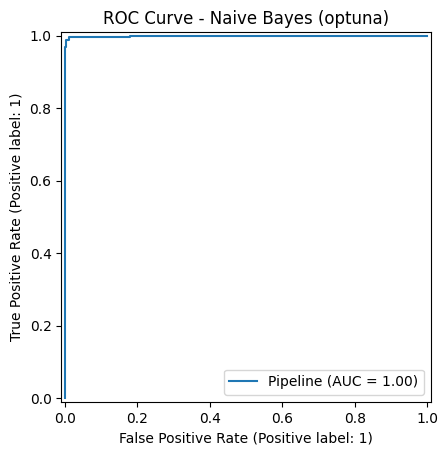

[I 2026-04-13 23:18:53,668] A new study created in memory with name: no-name-2c6320e0-201b-4912-8502-350faace582c



 Модель: SVC (Linear)
   Оптимизация (OPTUNA): SVC (Linear)


[I 2026-04-13 23:18:55,318] Trial 0 finished with value: 0.8307451632349347 and parameters: {'C': 10}. Best is trial 0 with value: 0.8307451632349347.
[I 2026-04-13 23:18:57,431] Trial 1 finished with value: 0.8307451632349347 and parameters: {'C': 10}. Best is trial 0 with value: 0.8307451632349347.
[I 2026-04-13 23:18:59,136] Trial 2 finished with value: 0.8273781319117873 and parameters: {'C': 1}. Best is trial 0 with value: 0.8307451632349347.
[I 2026-04-13 23:19:01,048] Trial 3 finished with value: 0.8273781319117873 and parameters: {'C': 1}. Best is trial 0 with value: 0.8307451632349347.
[I 2026-04-13 23:19:03,216] Trial 4 finished with value: 0.8382276831133862 and parameters: {'C': 100}. Best is trial 4 with value: 0.8382276831133862.
[I 2026-04-13 23:19:05,034] Trial 5 finished with value: 0.8273781319117873 and parameters: {'C': 1}. Best is trial 4 with value: 0.8382276831133862.
[I 2026-04-13 23:19:06,774] Trial 6 finished with value: 0.8273781319117873 and parameters: {'C'

   Optuna выбрала: {'C': 100}

Результаты 10-Fold CV для SVC (Linear)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.7388,0.7250,0.7643,0.7250
1,0.7677,0.7500,0.8252,0.7500
2,0.7575,0.7417,0.7955,0.7417
3,0.7300,0.7083,0.8007,0.7083
4,0.8571,0.8500,0.8766,0.8500
5,0.7721,0.7563,0.8177,0.7563
6,0.8238,0.8151,0.8443,0.8151
7,0.7685,0.7563,0.7933,0.7563
8,0.7901,0.7815,0.8060,0.7815


Test F1: 1.00 | Acc: 0.9983
Confusion Matrix:
 [[914   1]
 [  1 279]]


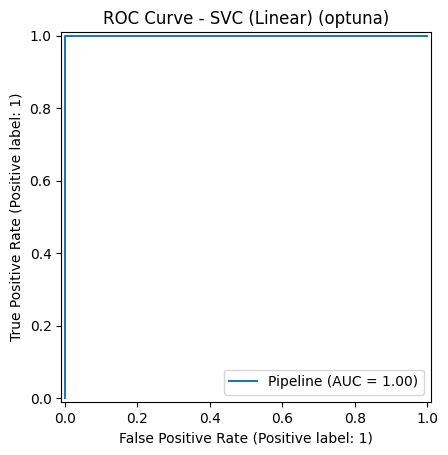


 Модель: SVC (Poly)
   Параметры для SVC (Poly) не заданы. Используется модель по умолчанию.

Результаты 10-Fold CV для SVC (Poly)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.7041,0.7167,0.6951,0.7167
1,0.6654,0.7667,0.5878,0.7667
2,0.6654,0.7667,0.5878,0.7667
3,0.6654,0.7667,0.5878,0.7667
4,0.6654,0.7667,0.5878,0.7667
5,0.6627,0.7647,0.5848,0.7647
6,0.6627,0.7647,0.5848,0.7647
7,0.6627,0.7647,0.5848,0.7647
8,0.6627,0.7647,0.5848,0.7647


Test F1: 0.99 | Acc: 0.9967
Confusion Matrix:
 [[912   3]
 [  1 279]]


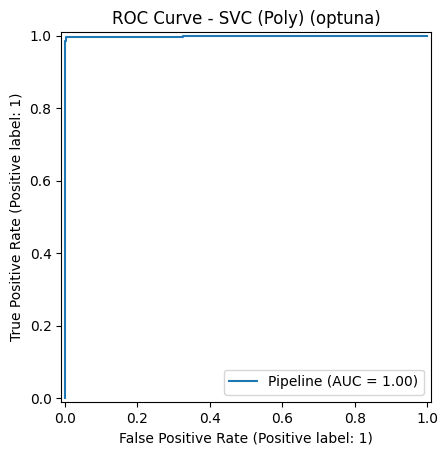

[I 2026-04-13 23:19:35,499] A new study created in memory with name: no-name-e5d6655c-f764-4b04-ad14-0f8e72b19357



 Модель: SVC (Sigmoid)
   Оптимизация (OPTUNA): SVC (Sigmoid)


[I 2026-04-13 23:19:37,476] Trial 0 finished with value: 0.8307451632349347 and parameters: {'C': 10, 'gamma': 'scale', 'coef0': 0.0}. Best is trial 0 with value: 0.8307451632349347.
[I 2026-04-13 23:19:39,261] Trial 1 finished with value: 0.8307451632349347 and parameters: {'C': 10, 'gamma': 'scale', 'coef0': 0.0}. Best is trial 0 with value: 0.8307451632349347.
[I 2026-04-13 23:19:44,154] Trial 2 finished with value: 0.9883394024713411 and parameters: {'C': 1, 'gamma': 'auto', 'coef0': 1.0}. Best is trial 2 with value: 0.9883394024713411.
[I 2026-04-13 23:19:48,329] Trial 3 finished with value: 0.9897972714509295 and parameters: {'C': 10, 'gamma': 'auto', 'coef0': -1.0}. Best is trial 3 with value: 0.9897972714509295.
[I 2026-04-13 23:19:50,052] Trial 4 finished with value: 0.8307451632349347 and parameters: {'C': 10, 'gamma': 'scale', 'coef0': 0.0}. Best is trial 3 with value: 0.9897972714509295.
[I 2026-04-13 23:19:54,451] Trial 5 finished with value: 0.7357926465265403 and paramet

   Optuna выбрала: {'C': 10, 'gamma': 'auto', 'coef0': -1.0}

Результаты 10-Fold CV для SVC (Sigmoid)


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.7815,0.8250,0.8575,0.8250
1,0.8139,0.8417,0.8522,0.8417
2,0.7747,0.8167,0.8271,0.8167
3,0.7306,0.7917,0.7933,0.7917
4,0.8067,0.8333,0.8333,0.8333
5,0.7797,0.8235,0.8566,0.8235
6,0.8069,0.8403,0.8679,0.8403
7,0.7653,0.8151,0.8511,0.8151
8,0.7997,0.8319,0.8432,0.8319


Test F1: 0.99 | Acc: 0.9975
Confusion Matrix:
 [[913   2]
 [  1 279]]


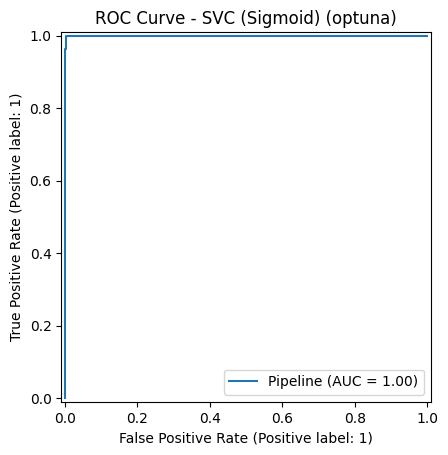

In [130]:
for METHOD in ['grid', 'random', 'optuna']:
    print(f"МЕТОД ОПТИМИЗАЦИИ: {METHOD.upper()}")


    current_holdout = []
    current_cv = []

    for name, base_clf in classifiers.items():
        print(f"\n Модель: {name}")
        
        best_clf, best_params = tune_model(base_clf, name, method=METHOD)
        
        cv_scores = cross_validate(
            best_clf, X_val, y_val, cv=cv_strategy,
            scoring=['f1_weighted', 'accuracy', 'precision_weighted', 'recall_weighted'], n_jobs=-1
        )
        cv_row = {"Classifier": f"{name}_{METHOD}"}
        for key, met in zip(['f1_weighted', 'accuracy', 'precision_weighted', 'recall_weighted'], metrics_list):
            mean_v, std_v = cv_scores[f'test_{key}'].mean(), cv_scores[f'test_{key}'].std()
            cv_row[('K-fold (CV)', met)] = f"{fmt(mean_v, met)} ± {fmt(std_v, met)}"
        current_cv.append(cv_row)
        
        if 'print_cv_results_table' in globals():
            print_cv_results_table(cv_scores, model_name=name)
        
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', best_clf)
        ])
        model.fit(X_train_bal, y_train_bal)
        trained_models[f"{name}_{METHOD}"] = model
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_m = calculate_metrics(y_train, y_train_pred)
        test_m = calculate_metrics(y_test, y_test_pred)
        
        ho_row = {"Classifier": f"{name}_{METHOD}"}
        for metric in metrics_list:
            ho_row[('Train Data', metric)] = fmt(train_m[metric], metric)
            ho_row[('Test Data', metric)]  = fmt(test_m[metric], metric)
        current_holdout.append(ho_row)
        
        print(f"Test F1: {test_m['F1']:.2f} | Acc: {test_m['Accuracy']:.4f}")
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
        
        RocCurveDisplay.from_estimator(model, X_test, y_test)
        plt.title(f'ROC Curve - {name} ({METHOD})')
        plt.show()

    holdout_results.extend(current_holdout)
    cv_results.extend(current_cv)

## Визуализации

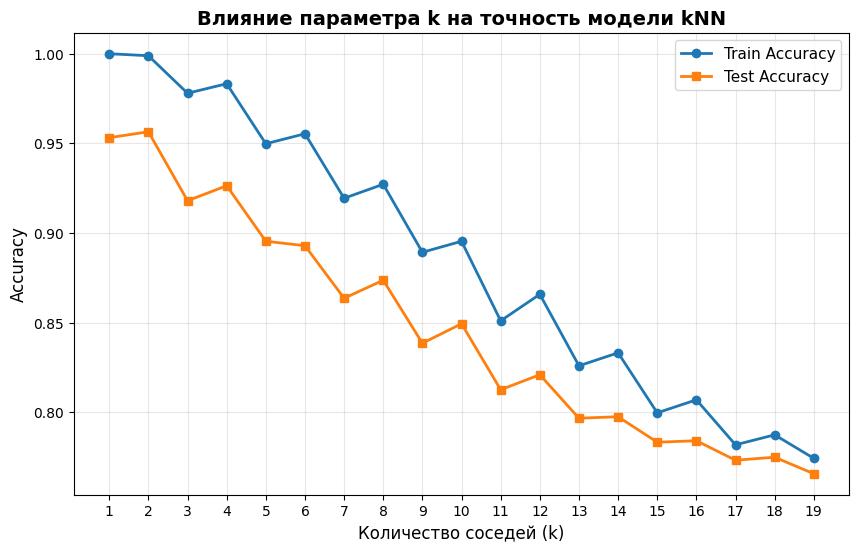

Оптимальное значение k: 2
Лучшая точность на тесте: 0.9565


In [131]:
k_values = range(1, 20)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal, y_train_bal)
    
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    
    train_scores.append(accuracy_score(y_train, y_train_pred))
    test_scores.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Train Accuracy', linewidth=2)
plt.plot(k_values, test_scores, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Влияние параметра k на точность модели kNN', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

optimal_k = k_values[np.argmax(test_scores)]
print(f"Оптимальное значение k: {optimal_k}")
print(f"Лучшая точность на тесте: {max(test_scores):.4f}")

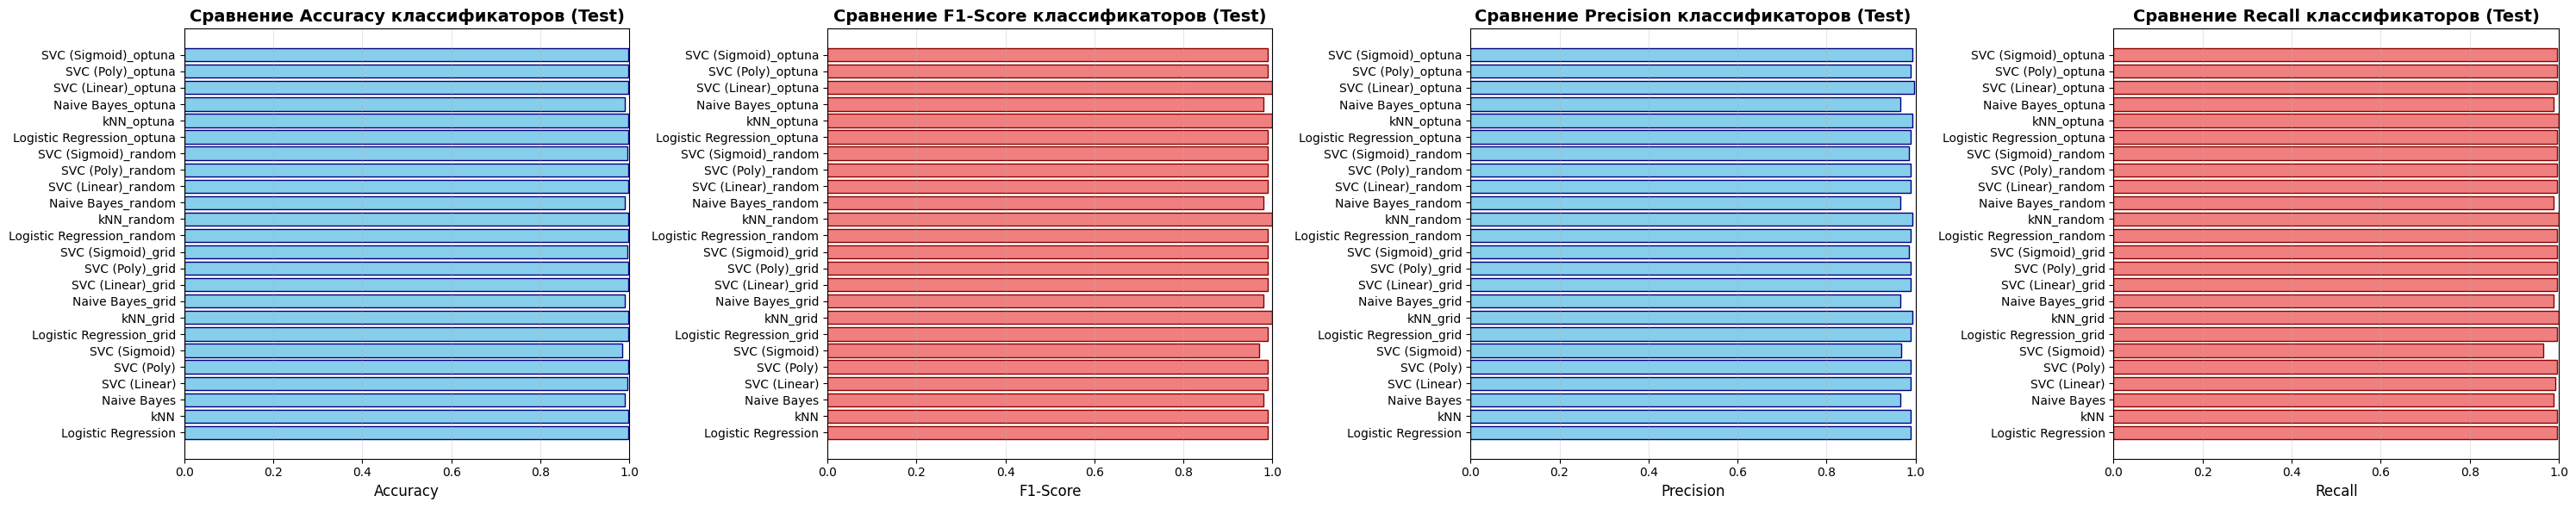

In [132]:
classifiers_names = [row['Classifier'] for row in holdout_results]
train_f1 = [float(row[('Train Data', 'F1')]) for row in holdout_results]
test_f1 = [float(row[('Test Data', 'F1')]) for row in holdout_results]
train_acc = [float(row[('Train Data', 'Precision')]) for row in holdout_results]
test_acc = [float(row[('Test Data', 'Accuracy')]) for row in holdout_results]
train_prec = [float(row[('Train Data', 'Precision')]) for row in holdout_results]
test_prec = [float(row[('Test Data', 'Precision')]) for row in holdout_results]
train_rec = [float(row[('Train Data', 'Recall')]) for row in holdout_results]
test_rec = [float(row[('Test Data', 'Recall')]) for row in holdout_results]

fig, axes = plt.subplots(1, 4, figsize=(30, 6))

axes[0].barh(classifiers_names, test_acc, color='skyblue', edgecolor='navy')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Сравнение Accuracy классификаторов (Test)', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(classifiers_names, test_f1, color='lightcoral', edgecolor='darkred')
axes[1].set_xlabel('F1-Score', fontsize=12)
axes[1].set_title('Сравнение F1-Score классификаторов (Test)', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 1])
axes[1].grid(axis='x', alpha=0.3)

axes[2].barh(classifiers_names, test_prec, color='skyblue', edgecolor='navy')
axes[2].set_xlabel('Precision', fontsize=12)
axes[2].set_title('Сравнение Precision классификаторов (Test)', fontsize=14, fontweight='bold')
axes[2].set_xlim([0, 1])
axes[2].grid(axis='x', alpha=0.3)

axes[3].barh(classifiers_names, test_rec, color='lightcoral', edgecolor='darkred')
axes[3].set_xlabel('Recall', fontsize=12)
axes[3].set_title('Сравнение Recall классификаторов (Test)', fontsize=14, fontweight='bold')
axes[3].set_xlim([0, 1])
axes[3].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

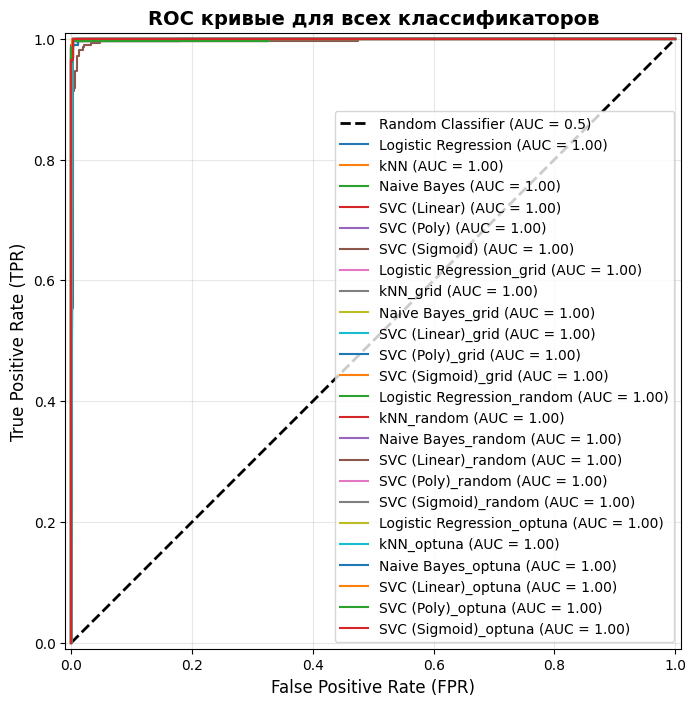

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name, plot_chance_level=False)

ax.set_title('ROC кривые для всех классификаторов', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модели демонстрирует очень низкое количество ошибок обоих типов: всего 3 ошибки первого рода (0.33% от всех белых вин) и 1 ошибка второго рода (0.36% от всех красных вин). Это свидетельствует о высокой сбалансированности модели и её способности одинаково хорошо распознавать оба класса вин. Ошибки первого рода немного преобладают, что может быть связано с дисбалансом классов в исходных данных.

## Собственный KNN

In [134]:
knn_sklearn = KNeighborsClassifier(n_neighbors=2)
knn_sklearn.fit(X_train_bal, y_train_bal)
y_pred_sklearn_train = knn_sklearn.predict(X_train)
y_pred_sklearn_test = knn_sklearn.predict(X_test)

metrics_sklearn = {
    'Train': calculate_metrics(y_train, y_pred_sklearn_train),
    'Test': calculate_metrics(y_test, y_pred_sklearn_test)
}

metrics_sklearn
knn_custom = MyKNNClassifier(n_neighbors=2, metric='euclidean')
knn_custom.fit(X_train_bal, y_train_bal)
y_pred_custom_train = knn_custom.predict(X_train)
y_pred_custom_test = knn_custom.predict(X_test)

metrics_custom = {
    'Train': calculate_metrics(y_train, y_pred_custom_train),
    'Test': calculate_metrics(y_test, y_pred_custom_test)
}

In [135]:
comparison_data = {
    ('Train Data', 'F1'): [metrics_sklearn['Train']['F1'], metrics_custom['Train']['F1']],
    ('Train Data', 'Accuracy'): [metrics_sklearn['Train']['Accuracy'], metrics_custom['Train']['Accuracy']],
    ('Train Data', 'Precision'): [metrics_sklearn['Train']['Precision'], metrics_custom['Train']['Precision']],
    ('Train Data', 'Recall'): [metrics_sklearn['Train']['Recall'], metrics_custom['Train']['Recall']],
    ('Test Data', 'F1'): [metrics_sklearn['Test']['F1'], metrics_custom['Test']['F1']],
    ('Test Data', 'Accuracy'): [metrics_sklearn['Test']['Accuracy'], metrics_custom['Test']['Accuracy']],
    ('Test Data', 'Precision'): [metrics_sklearn['Test']['Precision'], metrics_custom['Test']['Precision']],
    ('Test Data', 'Recall'): [metrics_sklearn['Test']['Recall'], metrics_custom['Test']['Recall']]
}

df = pd.DataFrame(comparison_data, index=['kNN из Sklearn', 'программный kNN'])
df.index.name = 'Classifier'

display(df.style.set_caption("Образец 1: Сравнение kNN из Sklearn и собственной реализации")
        .format({
            ('Train Data', 'F1'): '{:.2f}',
            ('Train Data', 'Accuracy'): '{:.4f}',
            ('Train Data', 'Precision'): '{:.4f}',
            ('Train Data', 'Recall'): '{:.4f}',
            ('Test Data', 'F1'): '{:.2f}',
            ('Test Data', 'Accuracy'): '{:.4f}',
            ('Test Data', 'Precision'): '{:.4f}',
            ('Test Data', 'Recall'): '{:.4f}'
        }))

Итоговые значения некоторых метрик совпадают, но большинство из собственного knn хуже sciket. При реализация из scikit отрабатывает за долю сенкуды, а собственнася реализация требует несоизмеримо большего времени (3 минуты). Собственная реализация knn намного хуже по производительности

## Таблицы результатов

In [136]:
cols_2 = pd.MultiIndex.from_product([
    ['Train Data', 'Test Data'], 
    ['F1', 'Accuracy', 'Precision', 'Recall']
])
df_sample2 = pd.DataFrame(holdout_results).set_index('Classifier').reindex(columns=cols_2)

display(df_sample2.style.set_caption("Образец 2: Сравнение Train и Test"))

Из таблицы видно, что модели хорошо отработали на обоих выборках, и их метрики почти не отличаются, что говорит об остуствии переобучения и недообучения. Между собой модели практически не отличаются

In [137]:
cols_3 = pd.MultiIndex.from_product([
    ['Метод hold-out (test)', 'Метод k-fold (кросс-валидация)'],
    ['F1', 'Accuracy', 'Precision', 'Recall']
])


holdout_metrics = ['F1', 'Accuracy', 'Precision', 'Recall']
kfold_metrics = ['F1 (среднее ± std)', 'Accuracy (среднее ± std)', 
                 'Precision (среднее ± std)', 'Recall (среднее ± std)']

cols_3 = pd.MultiIndex.from_tuples(
    [('Метод hold-out (test)', m) for m in holdout_metrics] +
    [('Метод k-fold (кросс-валидация)', m) for m in kfold_metrics]
)

data_rows = []
for cv_row, hold_row in zip(cv_results, holdout_results):
    row = {'Classifier': cv_row['Classifier']}
    
    for metric in holdout_metrics:
        row[('Метод hold-out (test)', metric)] = hold_row[('Test Data', metric)]
    
    for metric, kfold_metric in zip(holdout_metrics, kfold_metrics):
        row[('Метод k-fold (кросс-валидация)', kfold_metric)] = cv_row[('K-fold (CV)', metric)]
    
    data_rows.append(row)

df_sample3 = pd.DataFrame(data_rows).set_index('Classifier')
df_sample3.columns = cols_3

display(df_sample3.style.set_caption("Образец 3: Сравнение hold-out и k-fold кросс-валидации"))

Анализируя конечную таблицу матрик, можно сделать выводы что:

- Лучшие модели: `KNN` (при этом `KNN` имеет наибольшее `std`), `SVC(linear)`
- Худший результат: Naive Bayes
- Поиск лучших параметров улучшил результаты, при этом разницы между `grid`, `random` и `optuna` почти нет

Все модели имеют минимальные отличия и подходят для решения задачи классификации

## Общие выводы

**Поиск гиперпараметров:**  
Рассмотрены три метода — `GridSearchCV`, `RandomizedSearchCV` и `Optuna`. Все они показали идентичные результаты

**Классификационные модели:**  
Обучены модели: Logistic Regression, kNN, Naive Bayes, SVC (Linear), SVC (Poly), SVC (Sigmoid), а также их оптимизированные версии.

Среди всех моделей наилучший результат показал **kNN после настройки гиперпараметров (`kNN_optuna`)**:
- F1 на тесте = **1.00**, Accuracy = **0.9983**
- Минимальное количество ошибок I и II рода
- Настройка (`n_neighbors=1`, `metric='manhattan'`, `weights='distance'`) дала улучшение по сравнению с базовой версией

**Другие модели:**
- **Logistic Regression** и **SVC (Linear)** показали стабильно высокие результаты (F1 ≈ 0.99, Accuracy ≈ 0.996)
- **Naive Bayes** — худший результат среди всех моделей (F1 = 0.98)
- **SVC** методы показали такие же результаты, но при этом требует несоизмеримо большее время, что делает их использование нецелесообразным в этой задаче

**Стабильность моделей:**  
Разница метрик между Train и Test минимальна, что свидетельствует об отсутствии переобучения.

**Визуализация и метрики:**  
Использованы графики (ROC-кривые, сравнение метрик) и таблицы для анализа, а также метрики из `scikit-learn`.

**Лучшая модель — `kNN_optuna`.**: максимальные показатели F1 и Accuracy, минимальное количество ошибок, простота интерпретации, улучшение после оптимизации гиперпараметров.